# Forecast de Avistamentos de UFOs 👽

## Setup

### <span style="color:#39ff14">Importações e Dependências do Projeto</span>

Todas as bibliotecas do projeto estão centralizadas aqui e organizadas pela ordem em que aparecem no notebook. Isso facilita saber de onde vem cada função sem precisar procurar nos outros blocos.

- **pandas** e **matplotlib**: leitura do CSV e geração dos gráficos
- **statsmodels (tsaplots, seasonal, stattools)**: testes e decomposição da série temporal
- **numpy** e **warnings**: cálculos auxiliares dos basemodels e supressão de avisos de convergência
- **sklearn.metrics**: cálculo de MAE, MSE e RMSE
- **statsmodels SARIMAX**: ajuste e previsão do modelo SARIMA

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss

import numpy as np
import warnings

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX

### <span style="color:#39ff14">Carregamento do Dataset de Avistamentos de UFOs</span>

O dataset é o *UFO Sightings Scrubbed*, que contém registros de avistamentos de UFOs ao redor do mundo com data, hora, local e descrição. Aqui só carregamos a coluna `datetime` porque a análise é puramente temporal: o que importa é quantos avistamentos ocorreram por mês, não os detalhes de cada um. Já indexamos pelo datetime na leitura para facilitar o resample na próxima etapa.

In [2]:
raw_ts = pd.read_csv(
    'ufo_sightings_scrubbed.csv',
    usecols=['datetime'],
    index_col='datetime',
    parse_dates=['datetime'],
    date_format='%Y-%m-%d %H:%M:%S'
)

### <span style="color:#39ff14">Agregação Mensal: de Avistamentos Individuais para Série Temporal</span>

O dataset original tem uma linha por avistamento. Para criar uma série temporal, precisamos de uma frequência regular, então agrupamos tudo por mês e contamos os avistamentos de cada periodo. Usamos `resample('ME')` (Month End) porque queremos o último dia do mês como índice padrão, que é o formato que o SARIMA espera para inferir a sazonalidade anual.

In [3]:
ts = raw_ts.resample('ME').size()

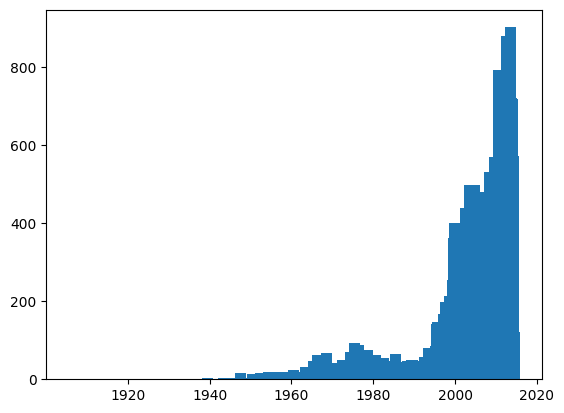

<Figure size 6400x800 with 0 Axes>

In [4]:
plt.bar(ts.index, ts.values, width=1000)
plt.figure(figsize=(64,8))
plt.show()

## Testando Estacionariedade e Sazonalidade

### <span style="color:#39ff14">Análise de Autocorrelação: ACF e PACF da Série Mensal</span>

A ACF (Autocorrelation Function) mostra o quanto o valor de um mês é correlacionado com os meses anteriores. A PACF (Partial ACF) faz o mesmo, mas remove o efeito dos lags intermediários, mostrando só a correlação direta com cada defasagem.

O que buscamos observar:
- Decaimento lento na ACF sugere tendência, ou seja, a série não é estacionária
- Picos regulares na ACF a cada 12 lags indicam sazonalidade anual
- Os primeiros lags significativos na PACF orientam o parâmetro `p` do modelo AR

Esses gráficos são o primeiro diagnóstico da série antes dos testes formais de estacionariedade.

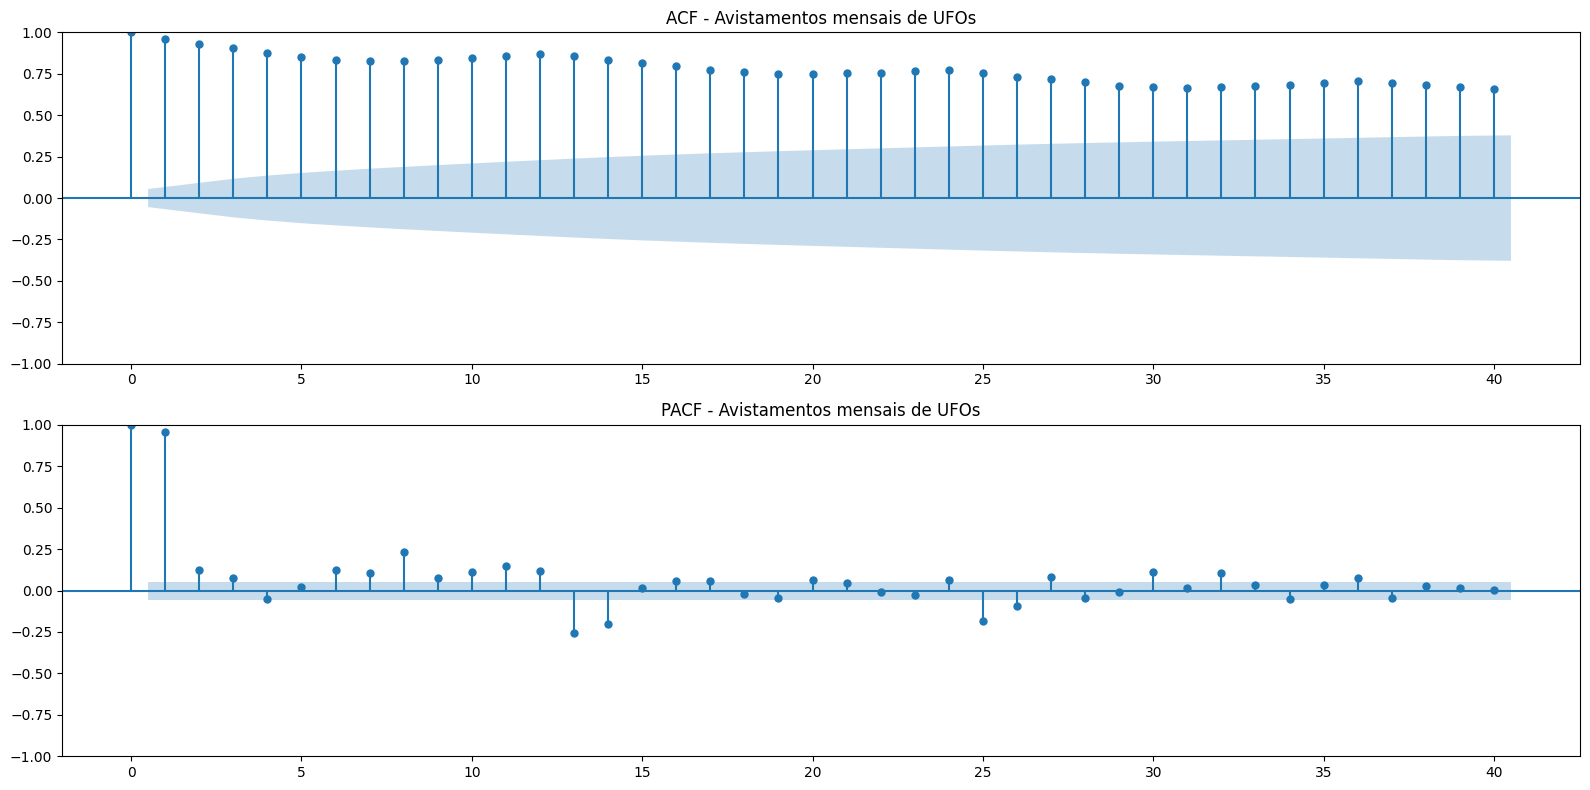

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

plot_acf(ts, lags=40, ax=axes[0], title='ACF - Avistamentos mensais de UFOs')
plot_pacf(ts, lags=40, ax=axes[1], title='PACF - Avistamentos mensais de UFOs')

plt.tight_layout()
plt.show()

### <span style="color:#39ff14">Decomposição STL: Tendência, Sazonalidade e Resíduo</span>

O STL (Seasonal-Trend decomposition using Loess) separa a série em três componentes: tendência, sazonalidade e resíduo. Isso ajuda a visualizar o quanto de cada fenômeno existe na série antes de modelar.

Escolhas feitas:
- `period=12`: sazonalidade anual (12 meses), que é o padrão esperado para avistamentos influenciados por estação do ano
- `seasonal=13`: janela de suavização sazonal (deve ser ímpar e maior que `period`)
- `robust=True`: usa pesos para reduzir o impacto de outliers na estimativa; sem isso, um único pico de avistamentos poderia distorcer toda a componente de tendência

Os valores de `F_trend` e `F_seasonal` quantificam a intensidade de cada componente numa escala de 0 a 1.

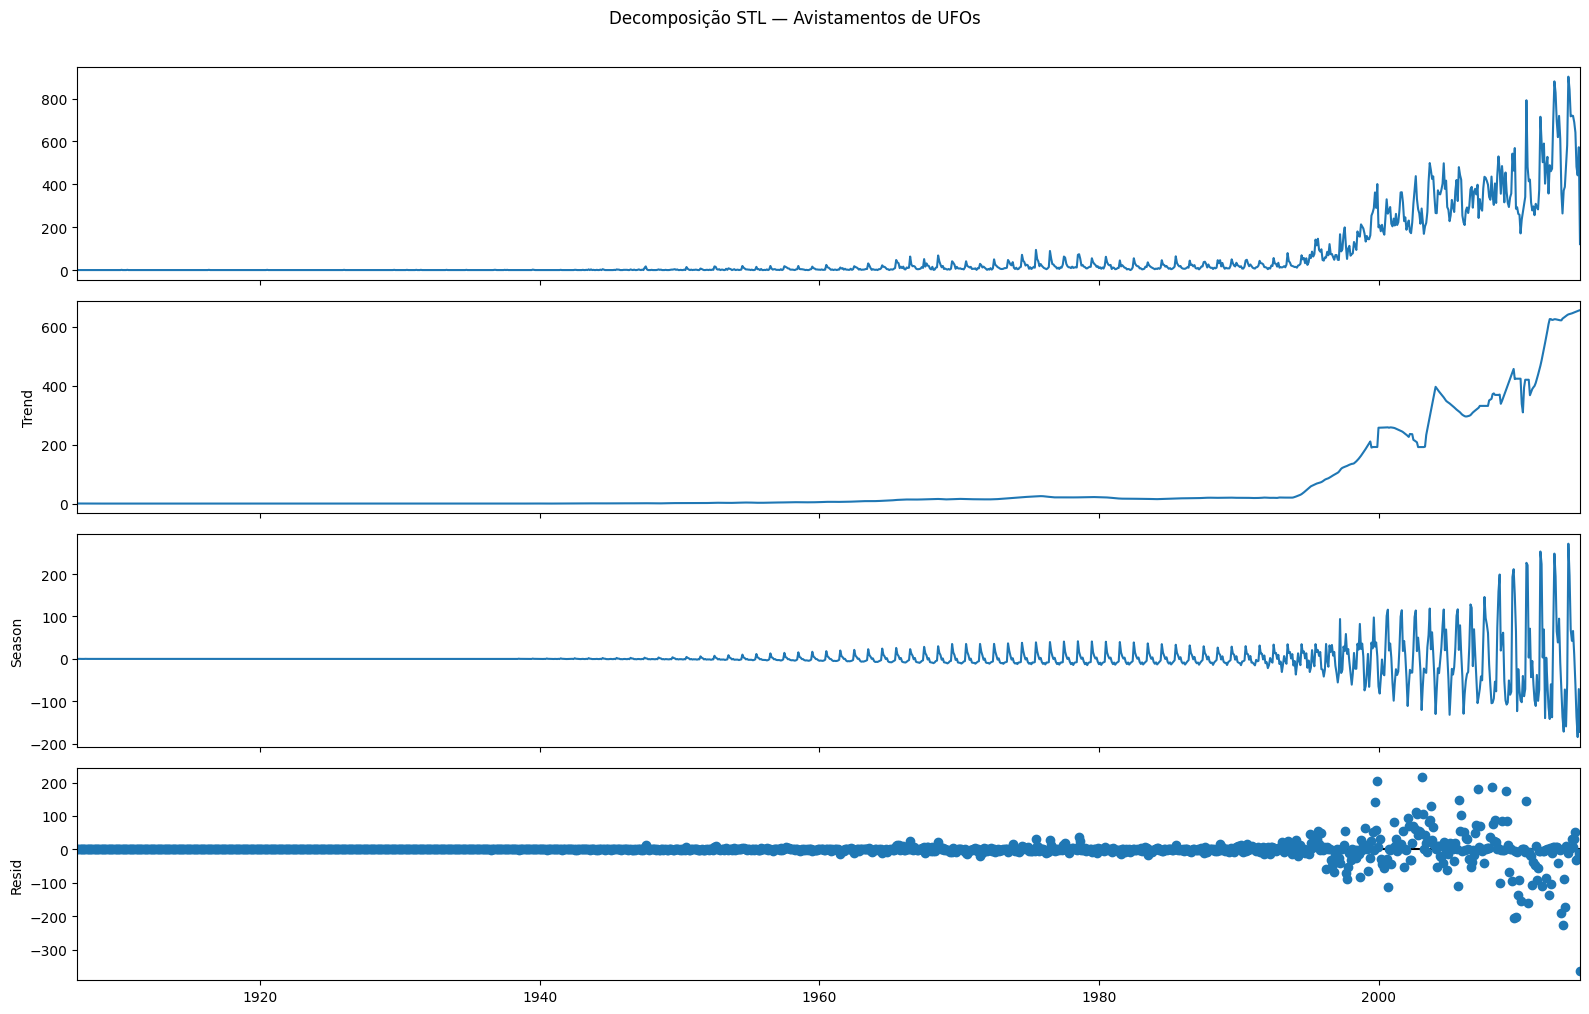

In [6]:
stl = STL(ts, period=12, seasonal=13, robust=True)
result = stl.fit()

fig = result.plot()
fig.set_size_inches(16, 10)
fig.suptitle('Decomposição STL — Avistamentos de UFOs', y=1.01)
plt.tight_layout()
plt.show()

In [7]:
trend, seasonal, resid = result.trend, result.seasonal, result.resid

F_trend = max(0, 1 - resid.var() / (trend + resid).var())
F_seasonal = max(0, 1 - resid.var() / (seasonal + resid).var())

print(f'Força de tendência   (F_T): {F_trend:.3f}')
print(f'Força de sazonalidade (F_S): {F_seasonal:.3f}')

Força de tendência   (F_T): 0.954
Força de sazonalidade (F_S): 0.582


### <span style="color:#39ff14">Teste ADF: Verificação de Raiz Unitária (Dickey-Fuller Aumentado)</span>

O ADF testa formalmente se a série tem raiz unitária, o que equivale a dizer que ela não é estacionária. A hipótese nula é a presença de raiz unitária.

Como interpretar:
- **p-valor < 0,05**: rejeitamos a hipótese nula, a série é estacionária
- **p-valor > 0,05**: não rejeitamos, a série provavelmente precisa de diferenciação (parâmetro `d` > 0 no SARIMA)

No caso desta série o p-valor é 1.0, o que indica fortemente que ela não é estacionária e vai precisar de diferenciação.

In [8]:
adf_ts = adfuller(ts.dropna())

print("Estatística ADF:", adf_ts[0])
print("p-valor:", adf_ts[1])
print("Valores críticos:", adf_ts[4])

Estatística ADF: 4.266907111636351
p-valor: 1.0
Valores críticos: {'1%': np.float64(-3.4355217427788793), '5%': np.float64(-2.8638238726872296), '10%': np.float64(-2.5679859566283705)}


### <span style="color:#39ff14">Teste KPSS: Confirmação da Não Estacionariedade</span>

O KPSS tem a hipótese nula oposta ao ADF: ele assume que a série *é* estacionária. Se rejeitarmos a hipótese nula do KPSS, confirmamos que a série não é estacionária.

Quando os dois testes apontam na mesma direção (ambos indicam não estacionária), o resultado é mais confiável. Quando divergem, a série pode ser "fracamente não estacionária" e o parâmetro `d` precisa de atenção extra.

Nesta série, ADF e KPSS concordam: a série não é estacionária, o que justifica usar `d=1` e `D=1` no SARIMA.

In [9]:
kpss_ts = kpss(ts.dropna(), regression='c', nlags='auto')

print("KPSS Estatística:", kpss_ts[0])
print("p-valor:", kpss_ts[1])
print("Valores críticos:", kpss_ts[3])

KPSS Estatística: 3.009411799789264
p-valor: 0.01
Valores críticos: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}


C:\Users\allanaabrego-ieg\AppData\Local\Temp\ipykernel_24456\2451046276.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_ts = kpss(ts.dropna(), regression='c', nlags='auto')


## Basemodels

### <span style="color:#39ff14">Implementação dos Sete Modelos de Baseline</span>

Antes de usar um modelo complexo como o SARIMA, é necessário ter uma linha de base para comparação. Os basemodels são modelos simples que não fazem suposições sofisticadas sobre a série, então qualquer modelo mais avançado precisa superá-los para justificar sua complexidade.

Os sete modelos implementados cobrem estratégias diferentes:
- **Média histórica**: usa a média de toda a série como previsão fixa
- **Média acumulada**: recalcula a média a cada passo com todos os dados até aquele momento
- **SMA (Simple Moving Average)**: média dos últimos `k` pontos
- **EMA (Exponential Moving Average)**: média ponderada, dando mais peso aos pontos recentes
- **Taxa de variação**: projeta a tendência recente de crescimento ou queda
- **Seasonal Naive**: repete o valor do mesmo mês do ano anterior
- **Delta**: extrapola a diferença entre os últimos dois pontos

In [10]:
def base_model_media_historica(serie):
    return pd.Series(serie.mean(), index=serie.index)

def base_model_media_acumulada(serie):
    previsao = [np.nan] + [serie.iloc[:i].mean() for i in range(1, len(serie))]
    return pd.Series(previsao, index=serie.index)

def base_model_sma(serie, k):
    return serie.rolling(window=k).mean().shift(1)

def base_model_ema(serie, alpha):
    return serie.ewm(alpha=alpha, adjust=False).mean().shift(1)

def base_model_taxa_variacao(serie, k):
    previsoes, indices = [], []
    for i in range(k, len(serie) - 1):
        va, vp = serie.iloc[i], serie.iloc[i - k]
        if vp == 0:
            continue
        previsoes.append(va * (1 + (va - vp) / vp))
        indices.append(serie.index[i + 1])
    return pd.Series(previsoes, index=indices)

def base_model_seasonal_naive(serie, s):
    return serie.shift(s)

def base_model_delta(serie, k):
    previsoes, indices = [], []
    for i in range(k, len(serie) - 1):
        va, vp = serie.iloc[i], serie.iloc[i - k]
        previsoes.append(va + (va - vp) / k)
        indices.append(serie.index[i + 1])
    return pd.Series(previsoes, index=indices)

### <span style="color:#39ff14">Separação Treino e Teste: Últimos 12 Meses Reservados para Avaliação</span>

Os últimos 12 meses são separados como conjunto de teste. Essa escolha de 12 meses é intencional: cobre um ciclo sazonal completo, o que significa que o modelo precisa acertar todos os padrões de estação do ano, não só um trecho parcial. Todo o restante da série vai para treino.

O ponto importante é que o conjunto de teste não é tocado durante o treinamento ou o tuning dos hiperparâmetros. Qualquer decisão de parâmetro é tomada olhando só para o treino, o que garante uma avaliação sem vazamento de dados.

In [11]:
# últimos 12 meses para teste, restante para treino
ts_teste  = ts[-12:]
ts_treino = ts[:-12]

print(f"Treino: {len(ts_treino)} meses "
      f"({ts_treino.index[0].strftime('%Y-%m')} a {ts_treino.index[-1].strftime('%Y-%m')})")
print(f"Teste:  {len(ts_teste)} meses "
      f"({ts_teste.index[0].strftime('%Y-%m')} a {ts_teste.index[-1].strftime('%Y-%m')})")


Treino: 1279 meses (1906-11 a 2013-05)
Teste:  12 meses (2013-06 a 2014-05)


### <span style="color:#39ff14">Previsão Recursiva de 12 Meses com Tuning de Hiperparâmetros no Treino</span>

A previsão segue um esquema recursivo: o modelo prevê um mês, coloca esse valor previsto no histórico e usa esse histórico atualizado para prever o mês seguinte. Isso simula a situação real onde não temos acesso aos valores futuros.

O tuning dos hiperparâmetros (`k` do SMA, `alpha` do EMA, etc.) é feito por busca exaustiva no conjunto de treino, minimizando o MAE internamente. Assim, quando os modelos chegam ao teste, já estão com os melhores parâmetros encontrados, sem ter visto nenhum dado de teste.

In [12]:
warnings.filterwarnings('ignore')

# tuning: seleciona o melhor hiperparâmetro por modelo usando apenas o treino
_tuning = []
for k in range(1, len(ts_treino) // 4 + 1):
    p = base_model_sma(ts_treino, k).dropna()
    _tuning.append(('SMA', k, mean_absolute_error(ts_treino[p.index], p)))
for a in np.round(np.arange(0.1, 1.0, 0.1), 2):
    p = base_model_ema(ts_treino, a).dropna()
    _tuning.append(('EMA', a, mean_absolute_error(ts_treino[p.index], p)))
for k in range(1, len(ts_treino) // 4 + 1):
    p = base_model_taxa_variacao(ts_treino, k)
    _tuning.append(('Taxa Variacao', k, mean_absolute_error(ts_treino[p.index], p)))
for s in [3, 6, 12, 24]:
    p = base_model_seasonal_naive(ts_treino, s).dropna()
    _tuning.append(('Seasonal Naive', s, mean_absolute_error(ts_treino[p.index], p)))
for k in range(1, len(ts_treino) // 4 + 1):
    p = base_model_delta(ts_treino, k)
    _tuning.append(('Delta', k, mean_absolute_error(ts_treino[p.index], p)))

_df = pd.DataFrame(_tuning, columns=['modelo', 'hiperparametro', 'mae_treino'])
melhores_hiperparametros = {}
for m in ['SMA', 'EMA', 'Taxa Variacao', 'Seasonal Naive', 'Delta']:
    sub = _df[_df['modelo'] == m]
    melhores_hiperparametros[m] = sub.loc[sub['mae_treino'].idxmin(), 'hiperparametro']

# funções de previsão 1 passo à frente
def _prever_media_historica(historico, media_fixa):
    return media_fixa

def _prever_media_acumulada(historico):
    return historico.mean()

def _prever_sma(historico, k):
    return historico.iloc[-k:].mean() if len(historico) >= k else historico.mean()

def _prever_ema(historico, alpha):
    return historico.ewm(alpha=alpha, adjust=False).mean().iloc[-1]

def _prever_taxa_variacao(historico, k):
    if len(historico) <= k:
        return historico.mean()
    va, vp = historico.iloc[-1], historico.iloc[-1 - k]
    if vp == 0:
        return va
    return va * (1 + (va - vp) / vp)

def _prever_seasonal_naive(historico, s):
    return historico.iloc[-s] if len(historico) >= s else historico.mean()

def _prever_delta(historico, k):
    if len(historico) <= k:
        return historico.mean()
    va, vp = historico.iloc[-1], historico.iloc[-1 - k]
    return va + (va - vp) / k

# previsão recursiva: 12 meses à frente sem usar dados reais do teste
media_fixa = ts_treino.mean()

modelos_recursivos = {
    'Media Historica': lambda h: _prever_media_historica(h, media_fixa),
    'Media Acumulada': lambda h: _prever_media_acumulada(h),
    'SMA':             lambda h: _prever_sma(h, int(melhores_hiperparametros['SMA'])),
    'EMA':             lambda h: _prever_ema(h, melhores_hiperparametros['EMA']),
    'Taxa Variacao':   lambda h: _prever_taxa_variacao(h, int(melhores_hiperparametros['Taxa Variacao'])),
    'Seasonal Naive':  lambda h: _prever_seasonal_naive(h, int(melhores_hiperparametros['Seasonal Naive'])),
    'Delta':           lambda h: _prever_delta(h, int(melhores_hiperparametros['Delta'])),
}

previsoes_teste = pd.DataFrame(index=ts_teste.index)
previsoes_teste['real'] = ts_teste.values

for nome, func in modelos_recursivos.items():
    historico = ts_treino.copy()
    prevs = []
    for data in ts_teste.index:
        p = func(historico)
        prevs.append(p)
        historico = pd.concat([historico, pd.Series([p], index=[data])])
    previsoes_teste[nome] = prevs

print(previsoes_teste.to_string())

            real  Media Historica  Media Acumulada    SMA         EMA  Taxa Variacao  Seasonal Naive       Delta
datetime                                                                                                        
2013-06-30   582        56.997654        56.997654  486.0  453.617686     608.752577             695  494.458333
2013-07-31   902        56.997654        56.997654  486.0  453.617686     762.509672             880  499.477431
2013-08-31   842        56.997654        56.997654  486.0  453.617686     955.102321             827  490.497323
2013-09-30   717        56.997654        56.997654  486.0  453.617686    1196.339505             695  485.976379
2013-10-31   720        56.997654        56.997654  486.0  453.617686    1498.507730             620  485.267061
2013-11-30   719        56.997654        56.997654  486.0  453.617686    1876.996796             719  480.903189
2013-12-31   690        56.997654        56.997654  486.0  453.617686    2351.083616            

### <span style="color:#39ff14">Métricas de Erro no Conjunto de Teste: MAE, RMSE e MAPE por Modelo</span>

Quatro métricas são calculadas para cada modelo no conjunto de teste:

- **MAE**: média dos erros absolutos. Trata todos os meses com o mesmo peso, não é afetado por picos isolados e é fácil de interpretar (unidade de avistamentos/mês)
- **MSE e RMSE**: penalizam erros grandes de forma quadrática, sendo mais sensíveis a meses onde o modelo errou muito
- **MAPE**: erro percentual médio. Facilita comparações entre periodos de alta e baixa, mas fica indefinido quando o valor real é zero

A ordenação pelo MAE define o melhor basemodel, que vai para a comparação final contra o SARIMA.

In [13]:
nomes_modelos = ['Media Historica', 'Media Acumulada', 'SMA', 'EMA',
                 'Taxa Variacao', 'Seasonal Naive', 'Delta']

y_real = previsoes_teste['real'].values

zeros = (y_real == 0).sum()
if zeros:
    print(f"Atencao: {zeros} ponto(s) com valor real = 0 serao ignorados no calculo do MAPE.")

metricas_lista = []
for modelo in nomes_modelos:
    y_prev = previsoes_teste[modelo].values

    mae  = mean_absolute_error(y_real, y_prev)
    mse  = mean_squared_error(y_real, y_prev)
    rmse = np.sqrt(mse)

    # exclui posições com y_real == 0 porque MAPE é indefinido nesses pontos
    mask = y_real != 0
    mape = np.mean(np.abs((y_real[mask] - y_prev[mask]) / y_real[mask])) * 100

    metricas_lista.append({'modelo': modelo, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'MAPE': mape})

metricas_teste = (pd.DataFrame(metricas_lista)
                    .sort_values('MAE')
                    .reset_index(drop=True))

print(metricas_teste.to_string(index=False))

melhor_modelo_nome = metricas_teste.iloc[0]['modelo']
melhor_modelo_mae  = float(metricas_teste.iloc[0]['MAE'])
print(f"\nMelhor modelo: {melhor_modelo_nome}  |  MAE = {melhor_modelo_mae:.2f}")

         modelo         MAE          MSE        RMSE       MAPE
 Seasonal Naive  122.833333 2.760717e+04  166.154045  40.960090
          Delta  200.674880 5.585044e+04  236.326983  48.572021
            SMA  202.166667 5.667600e+04  238.067217  48.625300
            EMA  223.088209 6.635990e+04  257.604150  49.698305
Media Historica  562.335679 3.551196e+05  595.919154  87.867754
Media Acumulada  562.335679 3.551196e+05  595.919154  87.867754
  Taxa Variacao 2198.915881 9.668040e+06 3109.347168 781.727148

Melhor modelo: Seasonal Naive  |  MAE = 122.83


## SARIMA

### <span style="color:#39ff14">Seleção dos Parâmetros SARIMA por Grid Search com Critério BIC</span>

O SARIMA (Seasonal AutoRegressive Integrated Moving Average) é um modelo que captura três tipos de padrão numa série temporal:

- **AR (p)**: correlação do valor atual com os valores passados
- **I (d)**: número de diferenciações para tornar a série estacionária
- **MA (q)**: correlação do valor atual com os erros de previsão passados
- **Parte sazonal (P, D, Q, s)**: os mesmos componentes, mas aplicados nos lags sazonais (múltiplos de `s=12`)

A seleção dos parâmetros é feita por busca em grid, testando todas as combinações de (p, d, q) x (P, D, Q) dentro de limites definidos. O critério de seleção é o **BIC**, que penaliza mais a complexidade do que o AIC, reduzindo o risco de overfitting em séries longas como esta.

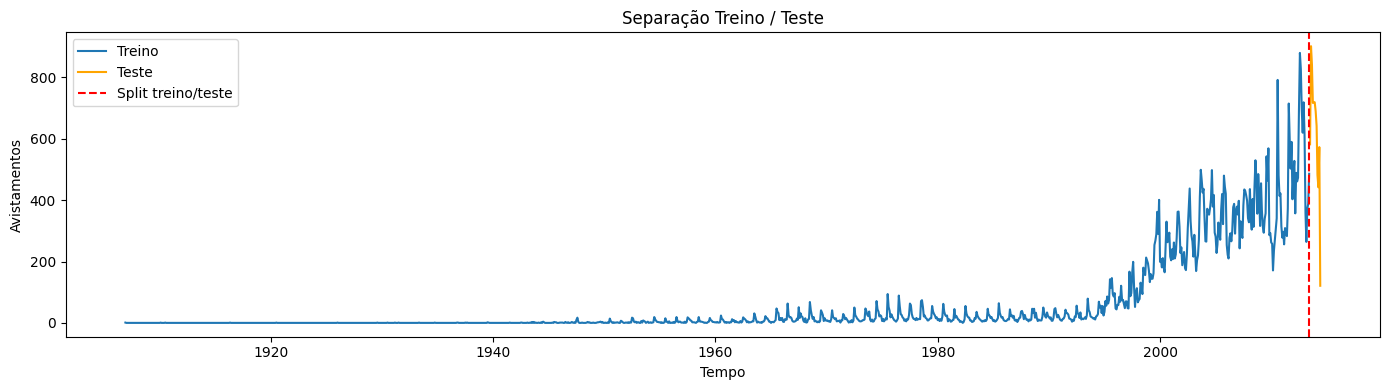

Treino: 1279 observações (1906-11-30 → 2013-05-31)
Teste:  12 observações (2013-06-30 → 2014-05-31)


In [14]:
h = 12  # horizonte de previsão: 12 meses
treino = ts[:-h]
teste = ts[-h:]

plt.figure(figsize=(14, 4))
plt.plot(treino.index, treino.values, label='Treino')
plt.plot(teste.index, teste.values, label='Teste', color='orange')
plt.axvline(treino.index[-1], ls='--', color='red', label='Split treino/teste')
plt.xlabel('Tempo')
plt.ylabel('Avistamentos')
plt.title('Separação Treino / Teste')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Treino: {len(treino)} observações ({treino.index[0].date()} → {treino.index[-1].date()})')
print(f'Teste:  {len(teste)} observações ({teste.index[0].date()} → {teste.index[-1].date()})')

In [15]:
s = 12  # sazonalidade mensal anual

resultados = []

for p in range(0, 3):
    for d in range(0, 2):
        for q in range(0, 3):
            for P in range(0, 2):
                for D in range(0, 2):
                    for Q in range(0, 2):
                        if p == 0 and d == 0 and q == 0 and P == 0 and D == 0 and Q == 0:
                            continue
                        try:
                            modelo = SARIMAX(
                                treino,
                                order=(p, d, q),
                                seasonal_order=(P, D, Q, s),
                                enforce_stationarity=False,
                                enforce_invertibility=False
                            ).fit(disp=False)
                            resultados.append({
                                'ordem': (p, d, q),
                                'ordem_sazonal': (P, D, Q, s),
                                'AIC': float(modelo.aic),
                                'BIC': float(modelo.bic),
                                'modelo': modelo
                            })
                        except Exception:
                            continue

# Ordenar por BIC e pegar top 10
resultados = sorted(resultados, key=lambda x: x['BIC'])
top10 = resultados[:10]

# Exibir tabela
print(f"{'#':<4} {'Ordem':<15} {'Sazonal':<18} {'AIC':>12} {'BIC':>12}")
print("-" * 63)
for i, r in enumerate(top10):
    print(f"{i+1:<4} {str(r['ordem']):<15} {str(r['ordem_sazonal']):<18} {r['AIC']:>12.2f} {r['BIC']:>12.2f}")

# Melhor modelo continua sendo o de menor BIC
melhor = top10[0]
melhor_ordem = melhor['ordem']
melhor_ordem_sazonal = melhor['ordem_sazonal']
melhor_modelo = melhor['modelo']

#    Ordem           Sazonal                     AIC          BIC
---------------------------------------------------------------
1    (1, 1, 2)       (0, 1, 1, 12)          11893.47     11919.13
2    (1, 1, 2)       (1, 1, 1, 12)          11895.34     11926.13
3    (2, 1, 2)       (0, 1, 1, 12)          11895.43     11926.22
4    (2, 1, 2)       (1, 1, 1, 12)          11897.30     11933.22
5    (2, 1, 1)       (0, 1, 1, 12)          11908.68     11934.35
6    (2, 1, 1)       (1, 1, 1, 12)          11910.64     11941.44
7    (1, 1, 1)       (0, 1, 1, 12)          11923.07     11943.60
8    (1, 0, 2)       (0, 1, 1, 12)          11924.86     11950.52
9    (1, 1, 1)       (1, 1, 1, 12)          11925.06     11950.72
10   (0, 1, 2)       (0, 1, 1, 12)          11930.23     11950.76


In [16]:
print(melhor_modelo.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                    y   No. Observations:                 1279
Model:             SARIMAX(1, 1, 2)x(0, 1, [1], 12)   Log Likelihood               -5941.734
Date:                              Sat, 23 May 2026   AIC                          11893.467
Time:                                      16:01:42   BIC                          11919.126
Sample:                                  11-30-1906   HQIC                         11903.113
                                       - 05-31-2013                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7816      0.020     39.743      0.000       0.743       0.820
ma.L1         -1.33

In [17]:
fc = melhor_modelo.get_forecast(steps=h)
mean = fc.predicted_mean
ci = fc.conf_int(alpha=0.05)

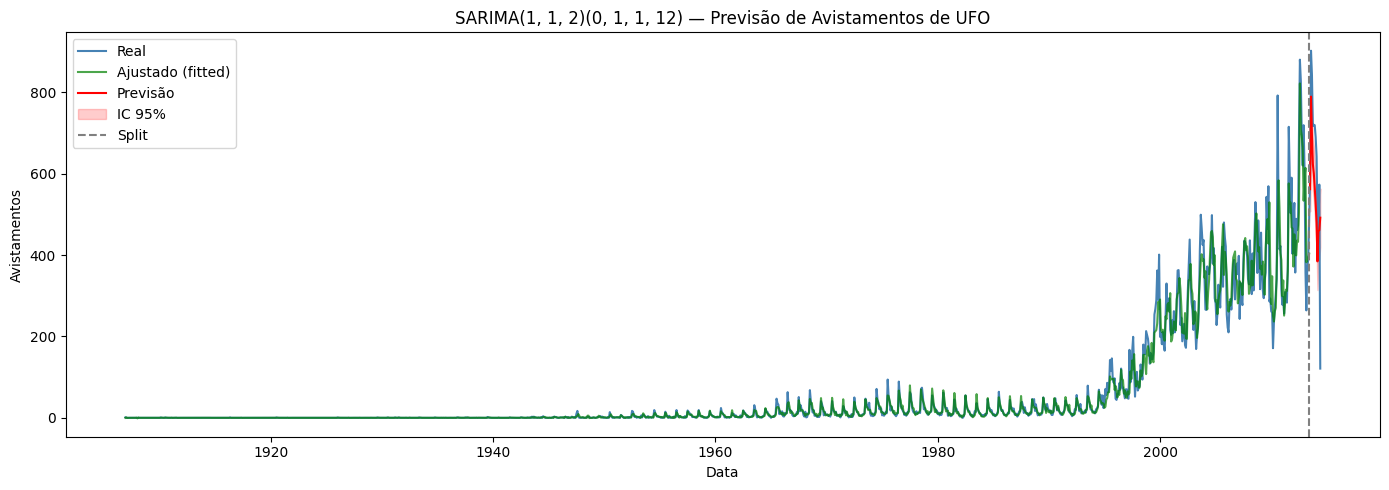

y                 mean    mean_se  mean_ci_lower  mean_ci_upper
2013-06-30  561.778493  27.898522     507.098395     616.458592
2013-07-31  789.180835  30.586288     729.232813     849.128857
2013-08-31  692.496460  32.310638     629.168773     755.824146
2013-09-30  623.330098  33.475651     557.719027     688.941169
2013-10-31  600.818239  34.296218     533.598887     668.037592
2013-11-30  566.224529  34.896241     497.829153     634.619905
2013-12-31  526.504799  35.350815     457.218476     595.791123
2014-01-31  479.120013  35.707082     409.135418     549.104607
2014-02-28  384.370035  35.995469     313.820213     454.919858
2014-03-31  458.740782  36.236081     387.719368     529.762196
2014-04-30  460.863735  36.442486     389.437775     532.289696
2014-05-31  491.717408  36.624018     419.935651     563.499164


In [18]:
fitted = melhor_modelo.fittedvalues
x_ci = ci.index.to_pydatetime()

plt.figure(figsize=(14, 5))
plt.plot(ts.index, ts.values, label='Real', color='steelblue')
plt.plot(fitted.index, fitted.values, label='Ajustado (fitted)', color='green', alpha=0.7)
plt.plot(mean.index, mean.values, label='Previsão', color='red')
plt.fill_between(x_ci, ci.iloc[:, 0].values, ci.iloc[:, 1].values, alpha=0.2, color='red', label='IC 95%')
plt.axvline(treino.index[-1], ls='--', color='gray', label='Split')
plt.xlabel('Data')
plt.ylabel('Avistamentos')
plt.title(f'SARIMA{melhor_ordem}{melhor_ordem_sazonal} — Previsão de Avistamentos de UFO')
plt.legend()
plt.tight_layout()
plt.show()

print(fc.summary_frame())

In [19]:
mae = mean_absolute_error(teste.values, mean.values)
print(f'MAE (Erro Absoluto Médio) no teste: {mae:.2f} avistamentos/mês')

MAE (Erro Absoluto Médio) no teste: 130.98 avistamentos/mês


### <span style="color:#39ff14">Diagnóstico dos Resíduos do SARIMA: Ljung-Box e ACF</span>

Depois de ajustar o SARIMA, é necessário verificar se os resíduos do modelo são ruído branco, ou seja, se não sobrou nenhuma estrutura que o modelo não capturou.

Duas ferramentas para isso:
- **Teste de Ljung-Box**: teste formal que verifica se existe autocorrelação significativa nos resíduos. Um p-valor alto indica que os resíduos são ruído branco e o modelo foi bem especificado
- **ACF dos resíduos**: versão visual da mesma análise. Se os lags estiverem dentro das bandas de confiança, o modelo capturou bem a série

Se os resíduos não passarem nesses testes, significa que o SARIMA ainda está deixando padrão na mesa e os parâmetros precisam ser revistos.


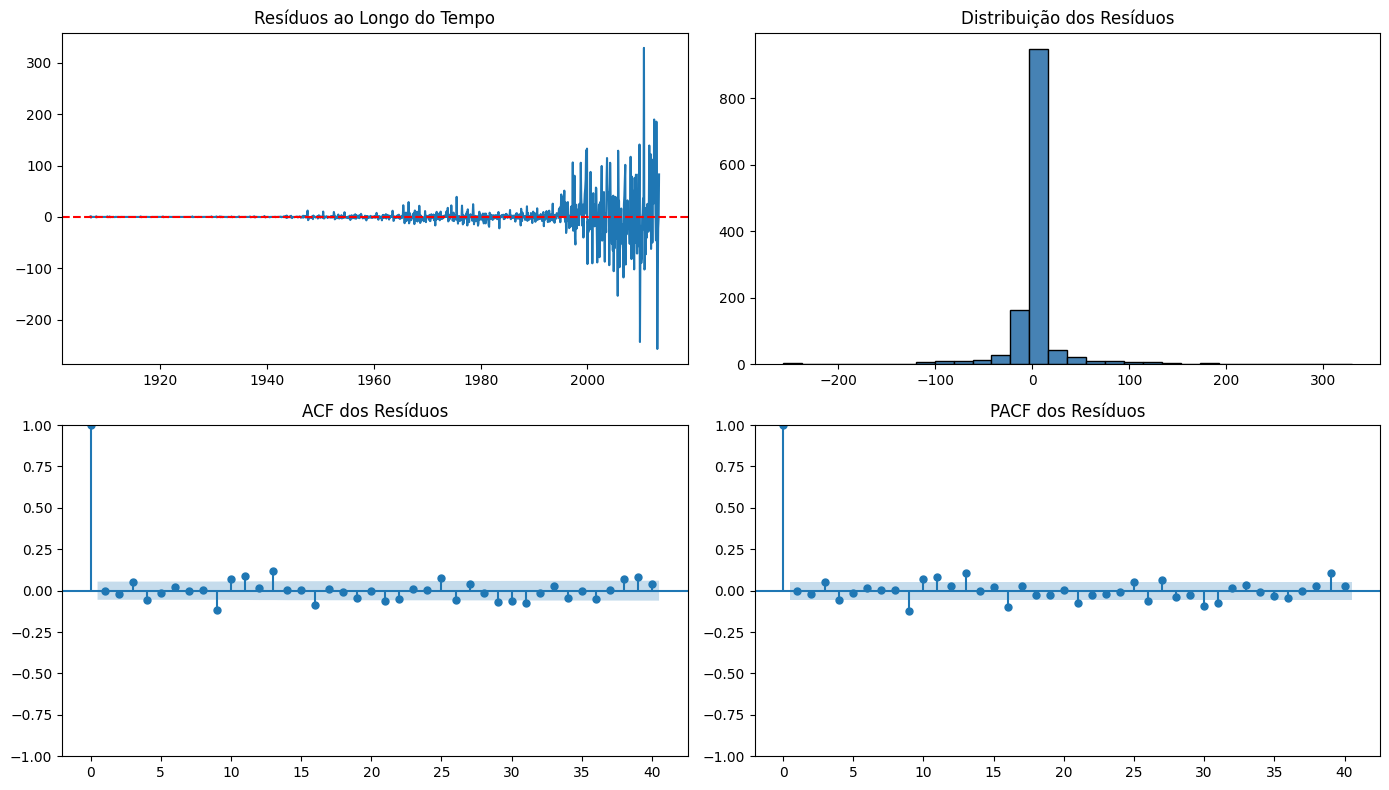


Teste de Ljung-Box:
       lb_stat     lb_pvalue
10   32.761483  2.986949e-04
20   74.090016  3.860961e-08
30  107.930571  9.982495e-11

  Lag 10: p-valor = 0.0003 — Autocorrelação restante
  Lag 20: p-valor = 0.0000 — Autocorrelação restante
  Lag 30: p-valor = 0.0000 — Autocorrelação restante

Ainda existe autocorrelação significativa em alguns lags, indicando que o modelo pode ser melhorado.


In [20]:
melhor_sarima = melhor_modelo
residuos = melhor_sarima.resid.dropna()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(residuos)
axes[0, 0].axhline(0, color='red', linestyle='--')
axes[0, 0].set_title('Resíduos ao Longo do Tempo')

axes[0, 1].hist(residuos, bins=30, edgecolor='black', color='steelblue')
axes[0, 1].set_title('Distribuição dos Resíduos')

plot_acf(residuos, lags=40, ax=axes[1, 0], title='ACF dos Resíduos')

plot_pacf(residuos, lags=40, ax=axes[1, 1], title='PACF dos Resíduos')

plt.tight_layout()
plt.show()

lb = acorr_ljungbox(residuos, lags=[10, 20, 30], return_df=True)
print("\nTeste de Ljung-Box:")
print(lb)
print()
for lag, row in lb.iterrows():
    status = "Ruído branco" if row['lb_pvalue'] > 0.05 else "Autocorrelação restante"
    print(f"  Lag {lag}: p-valor = {row['lb_pvalue']:.4f} — {status}")

# Observações rápidas
if (lb['lb_pvalue'] > 0.05).all():
    print('\nOs resíduos parecem ruído branco, sem autocorrelação significativa nos lags testados.')
else:
    print('\nAinda existe autocorrelação significativa em alguns lags, indicando que o modelo pode ser melhorado.')

### <span style="color:#39ff14">Rolling Forecast: Re-treinamento do Modelo a Cada Passo de Teste</span>

Na previsão estática feita acima, o modelo é treinado uma vez e prevê os 12 meses seguidos sem atualizar. O rolling forecast funciona diferente: a cada mês do teste, o modelo é re-treinado com todos os dados disponíveis até aquele ponto e faz a previsão de um passo à frente.

Isso é mais fiel ao uso real do modelo, porque em produção você sempre teria acesso ao último mês antes de prever o próximo. O rolling forecast tende a dar erros menores que a previsão estática, e a diferença entre os dois mostra o quanto o modelo se beneficia de ser atualizado com dados novos.


Rolling Forecast — Top 5 modelos:
  [1] SARIMA(1, 1, 2)x(0, 1, 1, 12): MAE Rolling = 90.6933
  [2] SARIMA(1, 1, 2)x(1, 1, 1, 12): MAE Rolling = 90.7877
  [3] SARIMA(2, 1, 2)x(0, 1, 1, 12): MAE Rolling = 90.4199
  [4] SARIMA(2, 1, 2)x(1, 1, 1, 12): MAE Rolling = 90.5394
  [5] SARIMA(2, 1, 1)x(0, 1, 1, 12): MAE Rolling = 88.4322

Melhor modelo no Rolling: SARIMA(2, 1, 1)x(0, 1, 1, 12)


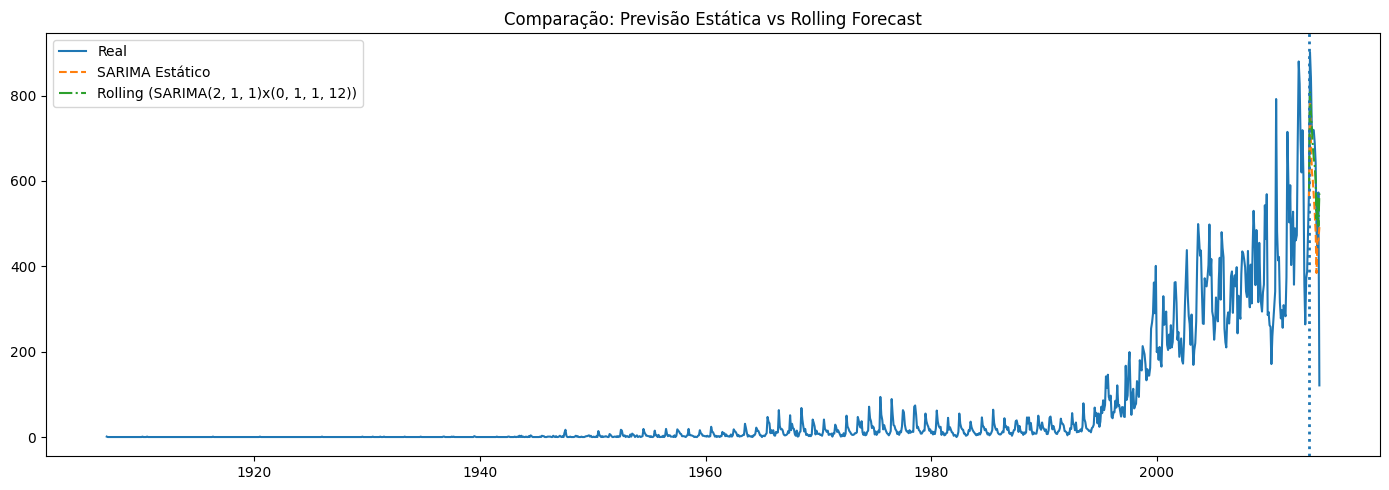


MAE SARIMA estático: 130.9809
MAE Rolling melhor:  88.4322


In [ ]:
def rolling_forecast_sarima(serie, train_size, order, seasonal_order, h=1):
    previsoes = []
    indices = []
    for i in range(len(serie) - train_size):
        window = serie.iloc[:train_size + i]
        try:
            modelo = SARIMAX(
                window,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False
            ).fit(disp=False)
            pred = modelo.forecast(steps=h)
            previsoes.append(pred.iloc[0])
        except Exception:
            previsoes.append(np.nan)
        indices.append(serie.index[train_size + i])
    return pd.Series(previsoes, index=indices)

serie = ts
train_size = len(treino)

models_list = top10 if 'top10' in globals() else resultados

print("Rolling Forecast — Top 5 modelos:")
resultados_rolling = {}

for i, r in enumerate(models_list[:5]):
    order = r.get('ordem', r.get('order'))
    seasonal = r.get('ordem_sazonal', r.get('seasonal_order'))
    preds = rolling_forecast_sarima(serie, train_size, order, seasonal, h=1)
    try:
        mae_roll = mean_absolute_error(teste.values, preds.values)
    except Exception:
        mae_roll = np.nan
    nome = f"SARIMA{order}x{seasonal}"
    resultados_rolling[nome] = {'mae': mae_roll, 'preds': preds}
    print(f"  [{i+1}] {nome}: MAE Rolling = {mae_roll:.4f}")

melhor_rolling_nome = min(resultados_rolling, key=lambda x: resultados_rolling[x]['mae'])
melhor_rolling_preds = resultados_rolling[melhor_rolling_nome]['preds']
print(f"\nMelhor modelo no Rolling: {melhor_rolling_nome}")

pred_sarima = mean
mae_sarima_teste = mean_absolute_error(teste.values, pred_sarima.values)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(serie, label='Real')
ax.plot(pred_sarima.index, pred_sarima.values, label='SARIMA Estático', linestyle='--')
ax.plot(melhor_rolling_preds.index, melhor_rolling_preds.values, label=f'Rolling ({melhor_rolling_nome})', linestyle='-.')
ax.axvline(x=teste.index[0], linestyle=':', linewidth=2)
ax.legend()
ax.set_title('Comparação: Previsão Estática vs Rolling Forecast')
plt.tight_layout()
plt.show()

print(f"\nMAE SARIMA estático: {mae_sarima_teste:.4f}")
print(f"MAE Rolling melhor:  {resultados_rolling[melhor_rolling_nome]['mae']:.4f}")


## Comparação: Melhor Basemodel vs SARIMA

Aqui colocamos lado a lado o melhor basemodel (identificado pelo menor MAE na seção anterior) e o SARIMA para responder a pergunta principal: o modelo complexo valeu a pena?

Se o SARIMA tiver MAE menor que o melhor basemodel, ele justifica sua complexidade. Se não, o modelo simples foi suficiente para essa série e usar o SARIMA seria over-engineering. O gráfico de barras abaixo deixa a comparação visual e direta.

Comparação de MAE: Melhor Basemodel vs SARIMA
                      modelo        MAE
              Seasonal Naive 122.833333
SARIMA(1, 1, 2)(0, 1, 1, 12) 130.980913


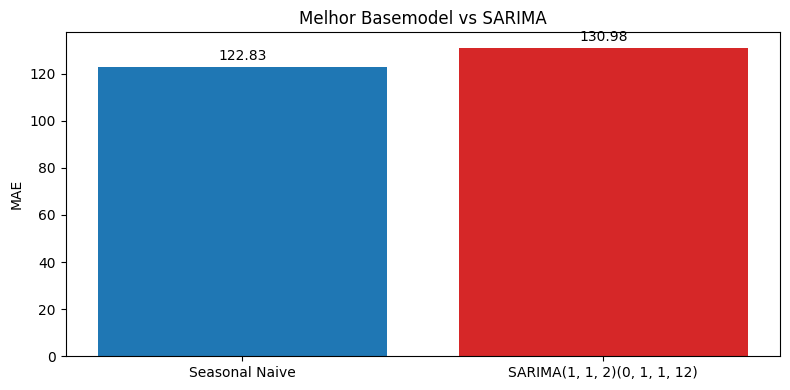

In [22]:
sarima_mae = mean_absolute_error(teste.values, mean.values)

comparacao = pd.DataFrame([
    {'modelo': melhor_modelo_nome,                           'MAE': melhor_modelo_mae},
    {'modelo': f'SARIMA{melhor_ordem}{melhor_ordem_sazonal}', 'MAE': sarima_mae},
])

print("Comparação de MAE: Melhor Basemodel vs SARIMA")
print(comparacao.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(comparacao['modelo'], comparacao['MAE'], color=['#1f77b4', '#d62728'])
ax.bar_label(bars, fmt='%.2f', padding=3)
ax.set_ylabel('MAE')
ax.set_title('Melhor Basemodel vs SARIMA')
plt.tight_layout()
plt.show()